Проверка качества данных

Анализ имеющихся данных,что нужно проверить:
| Проблема | Таблица для проверки | Что считаем нарушением / риском |
|---|---|---|
| Пользователь назначен в обе экспериментальные группы | `experiment_assignments.csv` | Один `user_id` имеет назначения и в Control, и в Test. Это нарушает чистоту сравнения групп. `assignment_source` поможет понять возможную причину. |
| Bot-like пользователи с необычно высокой активностью | `users.csv`, затем связанные `clicks.csv` и `impressions.csv` | `is_bot_candidate = 1` — не автоматическая ошибка, а кандидат на отдельную проверку и возможное исключение. Нужно оценить влияние на метрики и распределение между группами. |
| Пропущенная стоимость доставки | `orders.csv` | `delivery_fee_rub` имеет пропуск (`NULL` / пустое значение). Значение `0` само по себе не считаем ошибкой. |
| Дублирующиеся события показа | `impressions.csv` | `is_duplicate_event = 1`. Нужно определить, не исказят ли эти строки число показов и производные метрики. |
| Возвраты после окна наблюдения | `orders.csv` | У возвращённого заказа `return_date` находится позже окончания 30-дневного окна эксперимента. Это риск некорректного учёта возвратов в результатах теста. |

* Сначала конфликтующие назначения (уровень 1) — без этого сравнение групп нечестно
* Потом боты (уровень 1) — их поведение не репрезентативно
* Потом дубли показов (уровень 2) — искажают CTR
* Потом пропуски delivery_fee (уровень 2) — искажают метрики стоимости доставки
* В конце поздние возвраты (уровень 2) — искажают return rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Путь к данным
DATA_DIR = Path('../data/raw/soa_hackathon_2026_marketplace_dataset')

# Загружаем все таблицы сразу
users = pd.read_csv(DATA_DIR / 'users.csv')
assignments = pd.read_csv(DATA_DIR / 'experiment_assignments.csv')
sessions = pd.read_csv(DATA_DIR / 'sessions.csv')
impressions = pd.read_csv(DATA_DIR / 'impressions.csv')
clicks = pd.read_csv(DATA_DIR / 'clicks.csv')
orders = pd.read_csv(DATA_DIR / 'orders.csv')
products = pd.read_csv(DATA_DIR / 'products.csv')
sellers = pd.read_csv(DATA_DIR / 'sellers.csv')
support = pd.read_csv(DATA_DIR / 'support_tickets.csv')
premium = pd.read_csv(DATA_DIR / 'premium_subscriptions.csv')

print('Загружено таблиц: 10')
for name, df in [('users', users), ('assignments', assignments),
                 ('sessions', sessions), ('impressions', impressions),
                 ('clicks', clicks), ('orders', orders)]:
    print(f'{name:15} {df.shape[0]:>8} строк, {df.shape[1]:>2} колонок')

Загружено таблиц: 10
users              50000 строк,  8 колонок
assignments        50300 строк,  6 колонок
sessions          164739 строк,  9 колонок
impressions      1066434 строк,  9 колонок
clicks             91266 строк,  7 колонок
orders              7407 строк, 14 колонок


In [2]:
# Группируем по user_id и считаем два агрегата
user_stats = assignments.groupby('user_id').agg(
    assignment_count=('assignment_id', 'count'),      # COUNT(*)
    group_count=('experiment_group', 'nunique')       # COUNT(DISTINCT ...)
).reset_index()

# Оставляем только пользователей с повторными назначениями
conflicted_users = user_stats[user_stats['assignment_count'] > 1]

# Итоговая статистика
print(f'Всего пользователей: {len(user_stats)}')
print(f'С повторными назначениями: {len(conflicted_users)}')
print(f'Из них в обеих группах: {len(conflicted_users[conflicted_users["group_count"] > 1])}')

Всего пользователей: 50000
С повторными назначениями: 300
Из них в обеих группах: 300


### 1.1 Конфликтующие назначения в экспериментальные группы

**Что проверяем:** пользователи, которые оказались одновременно в Control и Test.

**Почему это важно:** если пользователь находится в обеих группах, мы не можем честно атрибутировать его действия (клики, заказы) к конкретной версии алгоритма. Это нарушает чистоту сравнения.

**Как проверяем:** группируем `experiment_assignments` по `user_id`, считаем число разных `experiment_group`, оставляем пользователей с `group_count > 1`.

In [3]:
# Находим пользователей с конфликтующими назначениями
conflicted_users = user_stats[user_stats['group_count'] > 1]['user_id'].tolist()

print(f'Создан список для исключения: {len(conflicted_users)} пользователей')

Создан список для исключения: 300 пользователей


### 1.2 Bot-like пользователи

**Что проверяем:** пользователей с флагом `is_bot_candidate = 1` — это кандидаты на исключение из-за подозрительно высокой активности.

**Почему это важно:** боты с аномальным поведением (много кликов, заказов) могут исказить метрики (CTR, GMV). Нужно оценить масштаб и проверить, не перекосили ли они одну из групп.

**Как проверяем:** считаем общее число ботов и их долю от всех пользователей.

In [4]:
# Считаем общее число пользователей
total_users = len(users)

# Считаем ботов: так как колонка содержит 0 и 1, сумма = количество единиц
bot_count = users['is_bot_candidate'].sum()

# Считаем долю в процентах
percent_bot = bot_count * 100.0 / total_users

print(f'Всего пользователей: {total_users}')
print(f'Ботов: {bot_count}')
print(f'Доля ботов: {percent_bot:.2f}%')

Всего пользователей: 50000
Ботов: 400
Доля ботов: 0.80%


**Результат:** 400 ботов (0.80% от всех пользователей) — ровно то, что обещано в README.

Теперь проверим, равномерно ли они распределены между Control и Test. Если 70% ботов оказались в Test, это может объяснить "улучшение" метрик.

**Как проверяем:** соединяем `users` с `experiment_assignments` по `user_id`, фильтруем ботов и считаем их по группам.

In [8]:
valid_assignments = assignments[
    ~assignments['user_id'].isin(conflicted_users)
]

bots_with_groups = users[
    users['is_bot_candidate'] == 1
].merge(
    valid_assignments[['user_id', 'experiment_group']],
    on='user_id',
    how='inner'
)

bot_distribution = (
    bots_with_groups
    .groupby('experiment_group')
    .size()
    .reset_index(name='bot_count')
)

print(bot_distribution)
print(f'Всего однозначно назначенных bot-like пользователей: {len(bots_with_groups)}')

  experiment_group  bot_count
0          control        201
1             test        198
Всего однозначно назначенных bot-like пользователей: 399


**Результат:**
- Всего bot-like пользователей: 400;
- один из них имеет конфликтующее назначение;
- среди 399 пользователей с однозначным назначением:
  - Control — 201;
  - Test — 198.

Существенного перекоса bot-like пользователей между группами не обнаружено.

**Решение:** исключить всех пользователей с `is_bot_candidate = 1` из основной аналитической выборки, поскольку их активность не считается репрезентативной для обычных пользователей.

In [6]:
# Создаём списки для исключения
conflicted_users = user_stats[user_stats['group_count'] > 1]['user_id'].tolist()
bot_users = users[users['is_bot_candidate'] == 1]['user_id'].tolist()

# Объединяем в множество
exclude_users = set(conflicted_users + bot_users)

# Создаём чистую выборку
clean_users = users[~users['user_id'].isin(exclude_users)]

print(f'Исключено пользователей: {len(exclude_users)}')
print(f'Осталось пользователей: {len(clean_users)}')
print(f'Доля исключённых: {len(exclude_users) / len(users) * 100:.2f}%')

Исключено пользователей: 699
Осталось пользователей: 49301
Доля исключённых: 1.40%


In [7]:
# Находим пользователей, которые есть в обоих списках
overlap = set(conflicted_users) & set(bot_users)

print(f'Пересечение списков: {len(overlap)} пользователей')
if len(overlap) > 0:
    print(f'Примеры user_id: {list(overlap)[:5]}')

Пересечение списков: 1 пользователей
Примеры user_id: ['u_011939']


**Интересная находка:**
Один пользователь (`u_011939`) одновременно является и конфликтующим (назначен в обе группы), и ботом.


### 1.3 Формирование основной выборки

Из анализа исключены 699 уникальных пользователей:
- 300 пользователей с конфликтующими назначениями;
- 400 bot-like пользователей;
- один пользователь входит в обе категории.

Основная выборка содержит 49 301 пользователя. Все дальнейшие пользовательские события будут фильтроваться по этому списку.

In [9]:
# Множество пользователей основной выборки
clean_user_ids = set(clean_users['user_id'])

# Фильтруем все таблицы с пользовательскими событиями
clean_assignments = assignments[
    assignments['user_id'].isin(clean_user_ids)
].copy()

clean_sessions = sessions[
    sessions['user_id'].isin(clean_user_ids)
].copy()

clean_impressions = impressions[
    impressions['user_id'].isin(clean_user_ids)
].copy()

clean_clicks = clicks[
    clicks['user_id'].isin(clean_user_ids)
].copy()

clean_orders = orders[
    orders['user_id'].isin(clean_user_ids)
].copy()

clean_support = support[
    support['user_id'].isin(clean_user_ids)
].copy()

clean_premium = premium[
    premium['user_id'].isin(clean_user_ids)
].copy()

for name, df in [
    ('assignments', clean_assignments),
    ('sessions', clean_sessions),
    ('impressions', clean_impressions),
    ('clicks', clean_clicks),
    ('orders', clean_orders),
    ('support', clean_support),
    ('premium', clean_premium)
]:
    print(f'{name:15} {len(df):>8} строк')

assignments        49301 строк
sessions          157302 строк
impressions      1018206 строк
clicks             83191 строк
orders              7327 строк
support              335 строк
premium             9009 строк


### 1.4 Дублирующиеся события показа

Проверим наличие повторяющихся `impression_id`, а также события, отмеченные признаком `is_duplicate_event = 1`. Такие записи могут завышать количество показов и искажать CTR и показатели пользовательской воронки.

In [10]:
duplicate_impression_ids = clean_impressions[
    'impression_id'
].duplicated(keep=False).sum()

duplicate_event_count = clean_impressions[
    'is_duplicate_event'
].eq(1).sum()

duplicate_event_share = (
    duplicate_event_count / len(clean_impressions) * 100
)

duplicate_event_users = clean_impressions.loc[
    clean_impressions['is_duplicate_event'].eq(1),
    'user_id'
].nunique()

print(f'Повторяющихся impression_id: {duplicate_impression_ids}')
print(f'Событий с is_duplicate_event = 1: {duplicate_event_count}')
print(f'Доля таких событий: {duplicate_event_share:.3f}%')
print(f'Затронуто пользователей: {duplicate_event_users}')

Повторяющихся impression_id: 0
Событий с is_duplicate_event = 1: 3046
Доля таких событий: 0.299%
Затронуто пользователей: 2922


**Результат:** повторяющихся значений `impression_id` не обнаружено. При этом 3 046 показов (0,299% показов основной выборки) отмечены как дублирующиеся события. Они относятся к 2 922 пользователям.

**Решение:** исключить строки с `is_duplicate_event = 1` из расчёта количества показов, CTR и воронки рекомендаций. Самих пользователей исключать не требуется, поскольку проблема относится к отдельным событиям логирования.

In [11]:
analysis_impressions = clean_impressions[
    clean_impressions['is_duplicate_event'].eq(0)
].copy()

print(f'Показов до очистки: {len(clean_impressions)}')
print(f'Показов после очистки: {len(analysis_impressions)}')
print(f'Удалено событий: {len(clean_impressions) - len(analysis_impressions)}')

Показов до очистки: 1018206
Показов после очистки: 1015160
Удалено событий: 3046


### 1.5 Пропуски стоимости доставки

Проверим количество пропусков в `delivery_fee_rub` и их распределение между экспериментальными группами. Значение `0` не считаем пропуском: оно может соответствовать бесплатной доставке.

In [12]:
# Добавляем к заказам экспериментальную группу пользователя
orders_with_group = clean_orders.merge(
    clean_assignments[['user_id', 'experiment_group']],
    on='user_id',
    how='left',
    validate='many_to_one'
)

delivery_fee_quality = (
    orders_with_group
    .groupby('experiment_group')
    .agg(
        order_count=('order_id', 'size'),
        missing_delivery_fee=(
            'delivery_fee_rub',
            lambda x: x.isna().sum()
        ),
        missing_share_pct=(
            'delivery_fee_rub',
            lambda x: x.isna().mean() * 100
        ),
        median_available_fee=('delivery_fee_rub', 'median')
    )
    .reset_index()
)

total_missing_fee = clean_orders['delivery_fee_rub'].isna().sum()
total_missing_share = (
    total_missing_fee / len(clean_orders) * 100
)
zero_delivery_fee = clean_orders['delivery_fee_rub'].eq(0).sum()

display(delivery_fee_quality)

print(f'Всего заказов: {len(clean_orders)}')
print(f'Пропущено delivery_fee_rub: {total_missing_fee}')
print(f'Доля пропусков: {total_missing_share:.2f}%')
print(f'Заказов с бесплатной доставкой: {zero_delivery_fee}')

,experiment_group,order_count,missing_delivery_fee,missing_share_pct,median_available_fee
0,control,3107,122,3.93,169.00
1,test,4220,178,4.22,163.00


Всего заказов: 7327
Пропущено delivery_fee_rub: 300
Доля пропусков: 4.09%
Заказов с бесплатной доставкой: 1722


**Результат:** значение `delivery_fee_rub` отсутствует у 300 из 7 327 заказов основной выборки, или у 4,09%. Доля пропусков близка в экспериментальных группах: 3,93% в Control и 4,22% в Test. Существенного перекоса пропусков между группами не обнаружено.

Значение `delivery_fee_rub = 0` встречается у 1 722 заказов и не считается ошибкой, поскольку может обозначать бесплатную доставку.

**Решение:** заказы с пропущенной стоимостью доставки не удаляем, поскольку поля `gmv_rub` и `gross_margin_rub` рассчитаны отдельно и доступны для анализа. При анализе самой стоимости доставки используем только заказы с известным значением и отмечаем это ограничение. Заполнять пропуски нулём нельзя, так как это ошибочно превратит неизвестную стоимость в бесплатную доставку.

### 1.6 Возвраты после окна наблюдения

Эксперимент продолжался 30 дней. Проверим границы экспериментального периода и определим, какая часть возвратов произошла после его окончания. Дополнительно сравним return rate с учётом всех известных возвратов и только возвратов внутри экспериментального окна.

In [13]:
# Преобразуем строки в даты
clean_sessions['session_date'] = pd.to_datetime(
    clean_sessions['session_date']
)

orders_with_group['order_date'] = pd.to_datetime(
    orders_with_group['order_date']
)

orders_with_group['return_date'] = pd.to_datetime(
    orders_with_group['return_date']
)

# Границы экспериментального периода
experiment_start = clean_sessions['session_date'].min()
experiment_end = clean_sessions['session_date'].max()

print(f'Начало эксперимента: {experiment_start.date()}')
print(f'Окончание эксперимента: {experiment_end.date()}')

Начало эксперимента: 2026-07-01
Окончание эксперимента: 2026-07-30


In [14]:
# Создаём отдельные признаки возврата
orders_with_group['returned_any_time'] = (
    orders_with_group['is_returned'].eq(1)
)

orders_with_group['returned_in_window'] = (
    orders_with_group['is_returned'].eq(1)
    & orders_with_group['return_date'].le(experiment_end)
)

orders_with_group['returned_after_window'] = (
    orders_with_group['is_returned'].eq(1)
    & orders_with_group['return_date'].gt(experiment_end)
)

total_returns = orders_with_group['returned_any_time'].sum()
returns_in_window = orders_with_group['returned_in_window'].sum()
returns_after_window = orders_with_group[
    'returned_after_window'
].sum()

late_return_share = (
    returns_after_window / total_returns * 100
)

print(f'Всего известных возвратов: {total_returns}')
print(f'Возвратов внутри окна: {returns_in_window}')
print(f'Возвратов после окна: {returns_after_window}')
print(f'Доля поздних возвратов: {late_return_share:.2f}%')
print(
    'Последняя дата возврата:',
    orders_with_group['return_date'].max().date()
)

Всего известных возвратов: 460
Возвратов внутри окна: 161
Возвратов после окна: 299
Доля поздних возвратов: 65.00%
Последняя дата возврата: 2026-09-04


In [17]:
return_quality_by_group = (
    orders_with_group
    .groupby('experiment_group')
    .agg(
        orders=('order_id', 'size'),
        returns_all=('returned_any_time', 'sum'),
        returns_in_window=('returned_in_window', 'sum'),
        returns_after_window=('returned_after_window', 'sum'),
        return_rate_all_pct=(
            'returned_any_time',
            lambda x: x.mean() * 100
        ),
        return_rate_in_window_pct=(
            'returned_in_window',
            lambda x: x.mean() * 100
        )
    )
    .reset_index()
)

display(return_quality_by_group)

,experiment_group,orders,returns_all,returns_in_window,returns_after_window,return_rate_all_pct,return_rate_in_window_pct
0,control,3107,172,62,110,5.54,2.00
1,test,4220,288,99,189,6.82,2.35


**Результат:** из 460 известных возвратов 299, или 65%, произошли после окончания 30-дневного экспериментального окна. Поэтому расчёт только по возвратам до 30 июля существенно недооценивает итоговую долю возвратов.

В Test return rate выше при обоих вариантах расчёта:

- с учётом всех известных возвратов: 6,82% против 5,54%;
- только внутри экспериментального окна: 2,35% против 2,00%.

Статистическую значимость этой разницы проверим позднее в разделе анализа A/B-теста.

**Решение:** поздние возвраты и связанные с ними заказы не удаляем, поскольку это реальные бизнес-результаты уже совершённых заказов. В основном анализе используем все известные возвраты, а показатель внутри 30-дневного окна приводим как проверку чувствительности результата. Отдельно отмечаем, что разная длительность наблюдения за заказами ограничивает точность оценки возвратов.

### 1.7 Общая структурная проверка таблиц

Помимо известных проблем проверим уникальность первичных ключей, пропуски и целостность связей между таблицами.

In [20]:
tables = {
    'users': users,
    'assignments': assignments,
    'sessions': sessions,
    'impressions': impressions,
    'clicks': clicks,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'support': support,
    'premium': premium
}

primary_keys = {
    'users': 'user_id',
    'assignments': 'assignment_id',
    'sessions': 'session_id',
    'impressions': 'impression_id',
    'clicks': 'click_id',
    'orders': 'order_id',
    'products': 'product_id',
    'sellers': 'seller_id',
    'support': 'ticket_id'
}

key_quality = []

for table_name, key in primary_keys.items():
    df = tables[table_name]

    key_quality.append({
        'table': table_name,
        'primary_key': key,
        'rows': len(df),
        'missing_key': df[key].isna().sum(),
        'duplicate_key': df[key].duplicated().sum()
    })

key_quality = pd.DataFrame(key_quality)

display(key_quality)

,table,primary_key,rows,missing_key,duplicate_key
0,users,user_id,50000,0,0
1,assignments,assignment_id,50300,0,0
2,sessions,session_id,164739,0,0
3,impressions,impression_id,1066434,0,0
4,clicks,click_id,91266,0,0
5,orders,order_id,7407,0,0
6,products,product_id,4500,0,0
7,sellers,seller_id,700,0,0
8,support,ticket_id,337,0,0


In [22]:
missing_values = []

for table_name, df in tables.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()

        if missing_count > 0:
            missing_values.append({
                'table': table_name,
                'column': column,
                'missing_count': missing_count,
                'missing_share_pct': (
                    missing_count / len(df) * 100
                )
            })

missing_values = pd.DataFrame(missing_values)

display(missing_values)

,table,column,missing_count,missing_share_pct
0,orders,delivery_fee_rub,303,4.09
1,orders,return_date,6945,93.76


In [23]:
unexpected_return_date_missing = orders[
    orders['is_returned'].eq(1)
    & orders['return_date'].isna()
]

return_date_for_nonreturned = orders[
    orders['is_returned'].eq(0)
    & orders['return_date'].notna()
]

print(
    'Возвратов без return_date:',
    len(unexpected_return_date_missing)
)

print(
    'Невозвращённых заказов с return_date:',
    len(return_date_for_nonreturned)
)

Возвратов без return_date: 0
Невозвращённых заказов с return_date: 0


In [27]:
from scipy.stats import chisquare
def count_missing_references(child_column, parent_column):
    """Считает значения дочерней таблицы, которых нет в родительской."""
    return (~child_column.isin(set(parent_column))).sum()


reference_checks = [
    {
        'relation': 'assignments → users',
        'missing_references': count_missing_references(
            assignments['user_id'], users['user_id']
        )
    },
    {
        'relation': 'sessions → users',
        'missing_references': count_missing_references(
            sessions['user_id'], users['user_id']
        )
    },
    {
        'relation': 'impressions → sessions',
        'missing_references': count_missing_references(
            impressions['session_id'], sessions['session_id']
        )
    },
    {
        'relation': 'impressions → products',
        'missing_references': count_missing_references(
            impressions['product_id'], products['product_id']
        )
    },
    {
        'relation': 'clicks → impressions',
        'missing_references': count_missing_references(
            clicks['impression_id'], impressions['impression_id']
        )
    },
    {
        'relation': 'orders → clicks',
        'missing_references': count_missing_references(
            orders['click_id'], clicks['click_id']
        )
    },
    {
        'relation': 'products → sellers',
        'missing_references': count_missing_references(
            products['seller_id'], sellers['seller_id']
        )
    },
    {
        'relation': 'support → users',
        'missing_references': count_missing_references(
            support['user_id'], users['user_id']
        )
    },
    {
        'relation': 'support → orders',
        'missing_references': count_missing_references(
            support['order_id'], orders['order_id']
        )
    },
    {
        'relation': 'premium → users',
        'missing_references': count_missing_references(
            premium['user_id'], users['user_id']
        )
    }
]

reference_checks = pd.DataFrame(reference_checks)

display(reference_checks)

,relation,missing_references
0,assignments → users,0
1,sessions → users,0
2,impressions → sessions,0
3,impressions → products,0
4,clicks → impressions,0
5,orders → clicks,0
6,products → sellers,0
7,support → users,0
8,support → orders,0
9,premium → users,0


In [28]:
group_counts = (
    clean_assignments['experiment_group']
    .value_counts()
    .sort_index()
)

group_shares = (
    group_counts / group_counts.sum() * 100
)

chi2_stat, srm_p_value = chisquare(
    group_counts.values
)

group_balance = pd.DataFrame({
    'users': group_counts,
    'share_pct': group_shares
}).reset_index()

display(group_balance)

print(f'Chi-square: {chi2_stat:.3f}')
print(f'p-value: {srm_p_value:.3f}')

,experiment_group,users,share_pct
0,control,24473,49.64
1,test,24828,50.36


Chi-square: 2.556
p-value: 0.110


**Результат структурной проверки:** первичные ключи заполнены и уникальны. Нарушений связей между основными таблицами не обнаружено. Пропуски присутствуют только в `delivery_fee_rub` и в ожидаемо незаполненных `return_date` для невозвращённых заказов.

После очистки в Control осталось 24 473 пользователя, а в Test — 24 828 пользователей. Проверка ожидаемого распределения 50/50 не выявила статистически значимого отклонения (`p-value = 0,110`). Признаков Sample Ratio Mismatch после очистки нет.

## 2. Исследовательский анализ данных (EDA)

Сначала рассмотрим структуру основной аудитории и сравним экспериментальные группы по устройствам, регионам, возрасту, источникам трафика, Premium-статусу и длительности присутствия пользователя на платформе.

In [34]:
analysis_users = clean_users.merge(
    clean_assignments[['user_id', 'experiment_group']],
    on='user_id',
    how='inner',
    validate='one_to_one'
)

analysis_users['registration_date'] = pd.to_datetime(
    analysis_users['registration_date']
)

analysis_users['tenure_days'] = (
    experiment_start
    - analysis_users['registration_date']
).dt.days

print(f'Пользователей в таблице: {len(analysis_users)}')
print(
    'Уникальных пользователей:',
    analysis_users['user_id'].nunique()
)

Пользователей в таблице: 49301
Уникальных пользователей: 49301


In [43]:
def calculate_category_shares(df, column):
    shares = pd.crosstab(
        df[column],
        df['experiment_group'],
        normalize='columns'
    ) * 100

    shares['difference_pp'] = (
        shares['test'] - shares['control']
    )

    return shares.round(2)

In [39]:
device_balance = calculate_category_shares(
    analysis_users, 'device'
)

region_balance = calculate_category_shares(
    analysis_users, 'region'
)

traffic_balance = calculate_category_shares(
    analysis_users, 'traffic_source'
)

age_balance = calculate_category_shares(
    analysis_users, 'age_group'
)

premium_balance = calculate_category_shares(
    analysis_users, 'is_premium'
)

display(device_balance)
display(region_balance)
display(traffic_balance)
display(age_balance)
display(premium_balance)

experiment_group,control,test,difference_pp
device,,,
android,57.41,58.25,0.84
ios,27.28,26.62,-0.67
web,15.31,15.14,-0.17


experiment_group,control,test,difference_pp
region,,,
Central Russia,21.95,21.85,-0.10
Far East,2.90,2.93,0.03
Moscow,17.97,17.96,-0.00
Saint Petersburg,8.65,9.22,0.57
Siberia,12.06,11.87,-0.19
South,9.22,9.14,-0.08
Ural,10.21,10.12,-0.09
Volga,17.03,16.90,-0.13


experiment_group,control,test,difference_pp
traffic_source,,,
affiliate,6.95,7.08,0.13
direct,11.51,12.01,0.50
email,8.17,7.71,-0.46
organic,42.38,42.20,-0.18
paid_ads,19.25,19.01,-0.24
push,11.74,11.99,0.26


experiment_group,control,test,difference_pp
age_group,,,
18-24,17.86,18.22,0.36
25-34,33.71,33.32,-0.39
35-44,25.16,25.47,0.30
45-54,15.11,15.00,-0.12
55+,8.15,8.00,-0.15


experiment_group,control,test,difference_pp
is_premium,,,
0,83.61,83.33,-0.28
1,16.39,16.67,0.28


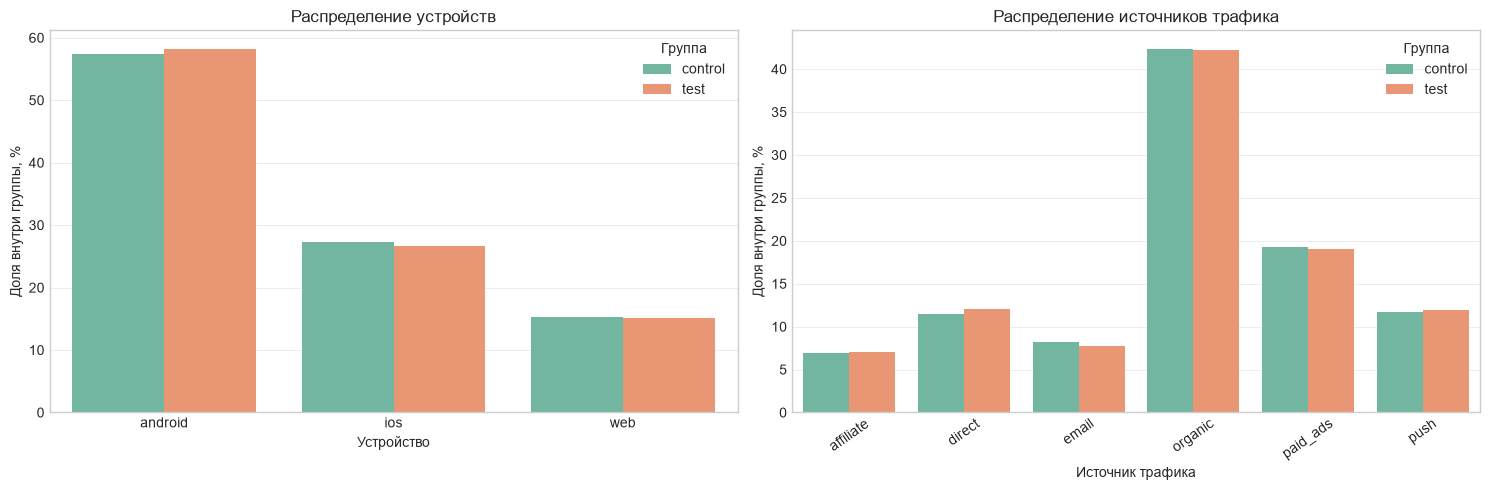

In [44]:
# Сначала самостоятельно рассчитываем доли устройств
device_plot = (
    analysis_users
    .groupby(['experiment_group', 'device'])
    .size()
    .reset_index(name='users')
)

device_plot['share_pct'] = (
    device_plot['users']
    / device_plot.groupby('experiment_group')['users'].transform('sum')
    * 100
)

# Аналогично рассчитываем доли источников трафика
traffic_plot = (
    analysis_users
    .groupby(['experiment_group', 'traffic_source'])
    .size()
    .reset_index(name='users')
)

traffic_plot['share_pct'] = (
    traffic_plot['users']
    / traffic_plot.groupby('experiment_group')['users'].transform('sum')
    * 100
)

# Строим графики по уже рассчитанным процентам
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5)
)

sns.barplot(
    data=device_plot,
    x='device',
    y='share_pct',
    hue='experiment_group',
    ax=axes[0]
)

axes[0].set_title('Распределение устройств')
axes[0].set_xlabel('Устройство')
axes[0].set_ylabel('Доля внутри группы, %')
axes[0].legend(title='Группа')

sns.barplot(
    data=traffic_plot,
    x='traffic_source',
    y='share_pct',
    hue='experiment_group',
    ax=axes[1]
)

axes[1].set_title('Распределение источников трафика')
axes[1].set_xlabel('Источник трафика')
axes[1].set_ylabel('Доля внутри группы, %')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Группа')

plt.tight_layout()
plt.show()

In [46]:
tenure_summary = (
    analysis_users
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'nunique'),
        mean_tenure_days=('tenure_days', 'mean'),
        median_tenure_days=('tenure_days', 'median'),
        std_tenure_days=('tenure_days', 'std')
    )
    .round(2)
    .reset_index()
)

display(tenure_summary)

,experiment_group,users,mean_tenure_days,median_tenure_days,std_tenure_days
0,control,24473,238.17,164.00,240.31
1,test,24828,239.25,165.00,238.76


### 2.5 Анализ пользовательской активности

Рассчитаем количество сессий, просмотров страниц, показов, кликов и заказов на уровне пользователя. Метрики считаются для всех участников эксперимента, включая пользователей без кликов и покупок.

In [47]:
analysis_clicks = clean_clicks[
    clean_clicks['impression_id'].isin(
        analysis_impressions['impression_id']
    )
].copy()

print(f'Кликов до очистки: {len(clean_clicks)}')
print(f'Кликов после очистки: {len(analysis_clicks)}')
print(f'Исключено кликов: {len(clean_clicks) - len(analysis_clicks)}')

Кликов до очистки: 83191
Кликов после очистки: 82916
Исключено кликов: 275


In [48]:
session_activity = (
    clean_sessions
    .groupby('user_id')
    .agg(
        sessions=('session_id', 'nunique'),
        total_page_views=('page_views', 'sum'),
        mean_session_duration=(
            'session_duration_sec', 'mean'
        )
    )
    .reset_index()
)

impression_activity = (
    analysis_impressions
    .groupby('user_id')
    .agg(
        impressions=('impression_id', 'nunique')
    )
    .reset_index()
)

click_activity = (
    analysis_clicks
    .groupby('user_id')
    .agg(
        clicks=('click_id', 'nunique')
    )
    .reset_index()
)

order_activity = (
    clean_orders
    .groupby('user_id')
    .agg(
        orders=('order_id', 'nunique'),
        gmv_rub=('gmv_rub', 'sum')
    )
    .reset_index()
)

In [49]:
user_activity = (
    analysis_users[
        ['user_id', 'experiment_group']
    ]
    .merge(
        session_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        impression_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        click_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        order_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
)

In [50]:
activity_columns = [
    'sessions',
    'total_page_views',
    'mean_session_duration',
    'impressions',
    'clicks',
    'orders',
    'gmv_rub'
]

user_activity[activity_columns] = (
    user_activity[activity_columns]
    .fillna(0)
)

In [52]:
activity_summary = (
    user_activity
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'size'),

        active_users=(
            'sessions',
            lambda x: (x > 0).sum()
        ),

        avg_sessions=('sessions', 'mean'),
        median_sessions=('sessions', 'median'),

        avg_page_views=(
            'total_page_views', 'mean'
        ),

        avg_impressions=('impressions', 'mean'),
        median_impressions=('impressions', 'median'),

        avg_clicks=('clicks', 'mean'),
        median_clicks=('clicks', 'median'),

        buyers=(
            'orders',
            lambda x: (x > 0).sum()
        ),

        avg_orders=('orders', 'mean'),
        avg_gmv_per_user=('gmv_rub', 'mean')
    )
    .round(3)
    .reset_index()
)

display(activity_summary)

,experiment_group,users,active_users,avg_sessions,median_sessions,avg_page_views,avg_impressions,median_impressions,avg_clicks,median_clicks,buyers,avg_orders,avg_gmv_per_user
0,control,24473,24473,3.19,3.00,22.33,20.62,19.00,1.51,1.00,2890,0.13,211.15
1,test,24828,24828,3.19,3.00,22.31,20.56,18.00,1.85,1.00,3767,0.17,286.42


In [53]:
buyer_rate = (
    user_activity
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'size'),
        buyers=('orders', lambda x: (x > 0).sum())
    )
)

buyer_rate['buyer_rate_pct'] = (
    buyer_rate['buyers']
    / buyer_rate['users']
    * 100
)

display(buyer_rate.round(2))

,users,buyers,buyer_rate_pct
experiment_group,,,
control,24473,2890,11.81
test,24828,3767,15.17


### Вывод по пользовательской активности

Интенсивность посещения маркетплейса практически одинакова между группами: в среднем 3,19 сессии и около 22,3 просмотра страниц на пользователя. Число показов рекомендаций также близко — около 20,6 на пользователя.

При сопоставимом количестве сессий и показов пользователи Test в среднем совершают больше кликов: 1,86 против 1,51. Доля пользователей хотя бы с одним заказом составляет около 15,17% в Test против 11,81% в Control. Средний GMV на участника эксперимента также выше: 286,42 рубля против 211,15 рубля.

Пока это описательные различия. Они ещё не доказывают эффект новой модели: статистическую значимость и размер эффекта проверим в разделе A/B-теста.

## 3. Анализ пользовательской воронки

Построим пользовательскую воронку:

участник эксперимента → показ → клик → заказ → возврат / повторная покупка.

Основная воронка считается на уровне уникальных пользователей. Дополнительно отдельно рассчитаем событийные CTR и Click-to-Order Conversion.

In [54]:
funnel_orders = clean_orders[
    clean_orders['click_id'].isin(
        analysis_clicks['click_id']
    )
].copy()

print(f'Показов в воронке: {len(analysis_impressions)}')
print(f'Кликов в воронке: {len(analysis_clicks)}')
print(f'Заказов в воронке: {len(funnel_orders)}')
print(
    'Заказов исключено из строгой воронки:',
    len(clean_orders) - len(funnel_orders)
)

Показов в воронке: 1015160
Кликов в воронке: 82916
Заказов в воронке: 7302
Заказов исключено из строгой воронки: 25


In [55]:
# Количество заказов каждого пользователя
user_order_counts = (
    funnel_orders
    .groupby('user_id')['order_id']
    .nunique()
)

# Пользователи хотя бы с одним возвратом
returned_user_ids = set(
    funnel_orders.loc[
        funnel_orders['is_returned'].eq(1),
        'user_id'
    ]
)

funnel_users = analysis_users[
    ['user_id', 'experiment_group']
].copy()

funnel_users['has_impression'] = (
    funnel_users['user_id'].isin(
        analysis_impressions['user_id']
    )
)

funnel_users['has_click'] = (
    funnel_users['user_id'].isin(
        analysis_clicks['user_id']
    )
)

funnel_users['has_order'] = (
    funnel_users['user_id'].isin(
        funnel_orders['user_id']
    )
)

funnel_users['has_return'] = (
    funnel_users['user_id'].isin(
        returned_user_ids
    )
)

funnel_users['is_repeat_buyer'] = (
    funnel_users['user_id']
    .map(user_order_counts)
    .fillna(0)
    .ge(2)
)

In [56]:
funnel_counts = (
    funnel_users
    .groupby('experiment_group')
    .agg(
        assigned_users=('user_id', 'size'),
        impression_users=('has_impression', 'sum'),
        click_users=('has_click', 'sum'),
        order_users=('has_order', 'sum'),
        return_users=('has_return', 'sum'),
        repeat_buyers=('is_repeat_buyer', 'sum')
    )
)

display(funnel_counts)

,assigned_users,impression_users,click_users,order_users,return_users,repeat_buyers
experiment_group,,,,,,
control,24473,24472,17488,2881,171,203
test,24828,24828,19238,3759,286,404


In [57]:
funnel_share = funnel_counts.copy()

funnel_share = (
    funnel_share
    .div(funnel_share['assigned_users'], axis=0)
    * 100
)

display(funnel_share.round(2))

,assigned_users,impression_users,click_users,order_users,return_users,repeat_buyers
experiment_group,,,,,,
control,100.00,100.00,71.46,11.77,0.70,0.83
test,100.00,100.00,77.49,15.14,1.15,1.63


In [58]:
funnel_conversion = pd.DataFrame(
    index=funnel_counts.index
)

funnel_conversion['impression_to_click_pct'] = (
    funnel_counts['click_users']
    / funnel_counts['impression_users']
    * 100
)

funnel_conversion['click_to_order_pct'] = (
    funnel_counts['order_users']
    / funnel_counts['click_users']
    * 100
)

funnel_conversion['order_to_return_pct'] = (
    funnel_counts['return_users']
    / funnel_counts['order_users']
    * 100
)

funnel_conversion['repeat_buyer_pct'] = (
    funnel_counts['repeat_buyers']
    / funnel_counts['order_users']
    * 100
)

display(funnel_conversion.round(2))

,impression_to_click_pct,click_to_order_pct,order_to_return_pct,repeat_buyer_pct
experiment_group,,,,
control,71.46,16.47,5.94,7.05
test,77.49,19.54,7.61,10.75


CTR = количество кликнутых показов / все показы

In [59]:
impressions_with_group = (
    analysis_impressions
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
)

orders_funnel_with_group = (
    funnel_orders
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
)

event_funnel = (
    impressions_with_group
    .groupby('experiment_group')
    .agg(
        impressions=('impression_id', 'size'),
        clicks=('is_clicked', 'sum')
    )
)

orders_by_group = (
    orders_funnel_with_group
    .groupby('experiment_group')
    .size()
)

event_funnel['orders'] = orders_by_group

event_funnel['ctr_pct'] = (
    event_funnel['clicks']
    / event_funnel['impressions']
    * 100
)

event_funnel['click_to_order_pct'] = (
    event_funnel['orders']
    / event_funnel['clicks']
    * 100
)

display(event_funnel.round(3))

,impressions,clicks,orders,ctr_pct,click_to_order_pct
experiment_group,,,,,
control,504604,36851,3098,7.30,8.41
test,510556,46065,4204,9.02,9.13


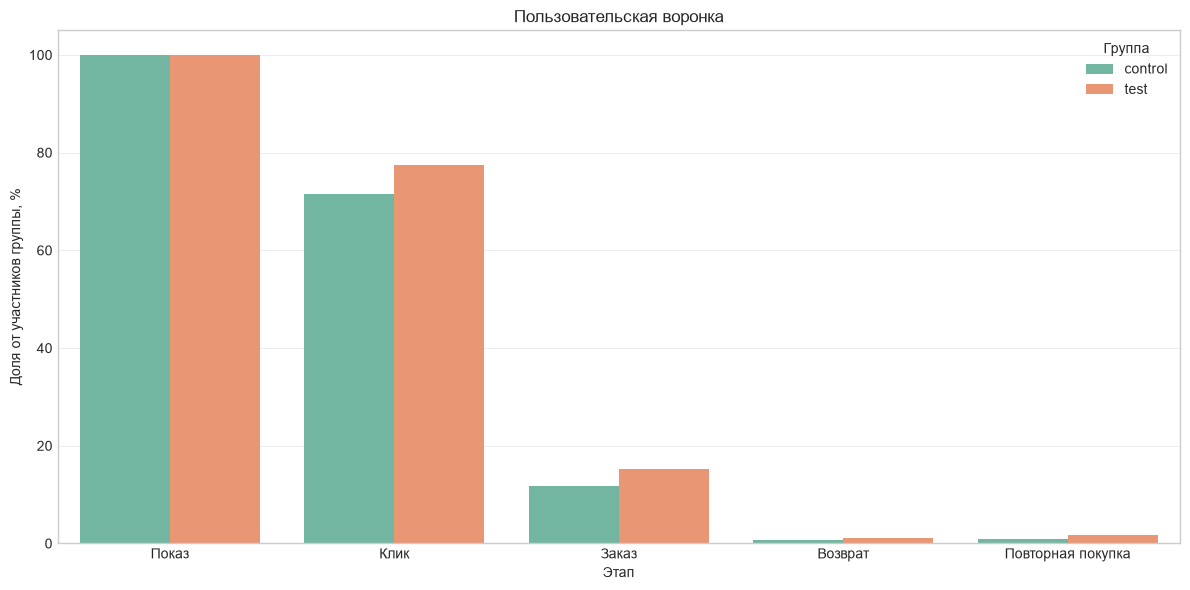

In [60]:
funnel_plot = (
    funnel_share[
        [
            'impression_users',
            'click_users',
            'order_users',
            'return_users',
            'repeat_buyers'
        ]
    ]
    .reset_index()
    .melt(
        id_vars='experiment_group',
        var_name='stage',
        value_name='share_pct'
    )
)

stage_labels = {
    'impression_users': 'Показ',
    'click_users': 'Клик',
    'order_users': 'Заказ',
    'return_users': 'Возврат',
    'repeat_buyers': 'Повторная покупка'
}

funnel_plot['stage'] = (
    funnel_plot['stage'].map(stage_labels)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=funnel_plot,
    x='stage',
    y='share_pct',
    hue='experiment_group'
)

plt.title('Пользовательская воронка')
plt.xlabel('Этап')
plt.ylabel('Доля от участников группы, %')
plt.legend(title='Группа')
plt.tight_layout()
plt.show()

In [61]:
print('1. Количество пользователей на каждом этапе')
display(funnel_counts)

print('2. Пользовательские конверсии между этапами')
display(funnel_conversion.round(2))

print('3. Событийная воронка')
display(event_funnel.round(3))

1. Количество пользователей на каждом этапе


,assigned_users,impression_users,click_users,order_users,return_users,repeat_buyers
experiment_group,,,,,,
control,24473,24472,17488,2881,171,203
test,24828,24828,19238,3759,286,404


2. Пользовательские конверсии между этапами


,impression_to_click_pct,click_to_order_pct,order_to_return_pct,repeat_buyer_pct
experiment_group,,,,
control,71.46,16.47,5.94,7.05
test,77.49,19.54,7.61,10.75


3. Событийная воронка


,impressions,clicks,orders,ctr_pct,click_to_order_pct
experiment_group,,,,,
control,504604,36851,3098,7.30,8.41
test,510556,46065,4204,9.02,9.13


### Вывод по пользовательской воронке

При практически полном охвате показами новая модель улучшает переход к целевым действиям. Хотя бы один клик совершили 77,49% пользователей Test против 71,46% в Control. До заказа дошли 15,14% пользователей Test против 11,77% в Control.

Событийный CTR составляет 9,02% в Test и 7,30% в Control. Click-to-Order Conversion также выше: 9,13% против 8,41%.

Одновременно в Test выше доля покупателей с возвратом: 7,61% против 5,94%. Доля повторных покупателей также выше: 10,75% против 7,05%.

Таким образом, новая модель предварительно улучшает клики, покупки и повторные покупки, но возможный рост возвратов представляет бизнес-риск. Статистическую значимость каждого различия проверим в разделе A/B-теста.

## 4. Анализ результатов A/B-теста

В предыдущем разделе были обнаружены различия между Control и Test в кликах, покупках, возвратах и повторных покупках. Однако само наличие различий ещё не доказывает влияние новой рекомендательной модели.

На этом этапе проверим статистическую значимость изменений и оценим не только направление, но и величину эффекта.

### 4.1 Выбор метрик

Для оценки результатов эксперимента используются:

- **CTR на пользователя** — характеризует интерес к рекомендациям;
- **конверсия в покупателя** — доля пользователей, совершивших хотя бы один заказ;
- **заказы на пользователя** — среднее количество заказов на одного участника эксперимента;
- **GMV на пользователя** — оборот маркетплейса на одного участника;
- **gross margin на пользователя** — краткосрочная коммерческая ценность пользователя;
- **доля повторных покупателей** — пользователи, совершившие не менее двух заказов;
- **Premium conversion** — доля новых подписчиков среди пользователей без Premium на начало эксперимента;
- **доля пользователей с возвратом** — защитная метрика качества покупок;
- **доля пользователей с обращением в поддержку** — защитная метрика пользовательского опыта.

Основными показателями для принятия решения считаются конверсия в покупателя и gross margin на пользователя. CTR показывает эффективность рекомендаций, а возвраты и обращения в поддержку используются как guardrail-метрики, ограничивающие допустимую цену роста.

### 4.2 Формирование пользовательской витрины

Поскольку единицей рандомизации является пользователь, перед статистическим анализом события агрегируются до уровня `user_id`.

Для каждого пользователя рассчитываются:

- количество показов и кликов;
- количество заказов;
- GMV и gross margin;
- количество возвратов;
- количество обращений в поддержку.

На следующем этапе агрегаты будут присоединены к полной таблице участников эксперимента. Пользователи без соответствующих событий останутся в выборке и получат нулевые значения.

In [63]:
# 1. Показы и клики на уровне пользователя
user_impressions = (
    analysis_impressions
    .groupby('user_id')
    .agg(
        impressions=('impression_id', 'nunique'),
        clicks=('is_clicked', 'sum')
    )
    .reset_index()
)

# 2. Заказы и их денежные показатели
user_orders = (
    funnel_orders
    .groupby('user_id')
    .agg(
        orders=('order_id', 'nunique'),
        gmv_rub=('gmv_rub', 'sum'),
        gross_margin_rub=('gross_margin_rub', 'sum'),
        returned_orders=('is_returned', 'sum')
    )
    .reset_index()
)

# 3. Оставляем обращения, относящиеся к чистой цепочке заказов
analysis_support = clean_support[
    clean_support['order_id'].isin(
        funnel_orders['order_id']
    )
].copy()

# 4. Обращения в поддержку на уровне пользователя
user_support = (
    analysis_support
    .groupby('user_id')
    .agg(
        support_tickets=('ticket_id', 'nunique')
    )
    .reset_index()
)

print('Агрегаты показов:')
display(user_impressions.head())

print('Агрегаты заказов:')
display(user_orders.head())

print('Агрегаты поддержки:')
display(user_support.head())

print('Размеры таблиц:')
print(f'Пользователей с показами: {len(user_impressions)}')
print(f'Покупателей: {len(user_orders)}')
print(f'Пользователей с обращениями: {len(user_support)}')

Агрегаты показов:


,user_id,impressions,clicks
0,u_000001,15,1
1,u_000002,6,0
2,u_000003,21,1
3,u_000004,14,0
4,u_000005,25,1


Агрегаты заказов:


,user_id,orders,gmv_rub,gross_margin_rub,returned_orders
0,u_000007,1,4374,879.17,0
1,u_000020,1,2690,407.27,0
2,u_000024,1,189,28.92,0
3,u_000028,1,614,127.83,0
4,u_000037,1,363,50.31,0


Агрегаты поддержки:


,user_id,support_tickets
0,u_000020,1
1,u_000060,1
2,u_000303,1
3,u_000374,1
4,u_000399,1


Размеры таблиц:
Пользователей с показами: 49300
Покупателей: 6640
Пользователей с обращениями: 332


In [65]:
metric_users = (
    analysis_users
    .merge(
        user_impressions,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        user_orders,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        user_support,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
)

print(f'Строк в пользовательской витрине: {len(metric_users)}')
print(f'Уникальных пользователей: {metric_users["user_id"].nunique()}')

display(metric_users.head())

Строк в пользовательской витрине: 49301
Уникальных пользователей: 49301


,user_id,registration_date,region,device,age_group,traffic_source,is_premium,is_bot_candidate,experiment_group,tenure_days,impressions,clicks,orders,gmv_rub,gross_margin_rub,returned_orders,support_tickets
0,u_000001,2026-04-29,Volga,android,18-24,paid_ads,0,0,control,63,15.00,1.00,NaN,NaN,NaN,NaN,NaN
1,u_000002,2026-02-25,Central Russia,android,35-44,direct,0,0,test,126,6.00,0.00,NaN,NaN,NaN,NaN,NaN
2,u_000003,2026-04-01,Moscow,web,18-24,push,1,0,control,91,21.00,1.00,NaN,NaN,NaN,NaN,NaN
3,u_000004,2026-03-08,Ural,ios,25-34,paid_ads,0,0,control,115,14.00,0.00,NaN,NaN,NaN,NaN,NaN
4,u_000005,2025-07-28,Central Russia,android,18-24,organic,1,0,test,338,25.00,1.00,NaN,NaN,NaN,NaN,NaN


In [66]:
zero_columns = [
    'impressions',
    'clicks',
    'orders',
    'gmv_rub',
    'gross_margin_rub',
    'returned_orders',
    'support_tickets'
]

metric_users[zero_columns] = (
    metric_users[zero_columns].fillna(0)
)

print('Количество пропусков после заполнения:')
display(metric_users[zero_columns].isna().sum())

Количество пропусков после заполнения:


impressions         0
clicks              0
orders              0
gmv_rub             0
gross_margin_rub    0
returned_orders     0
support_tickets     0
dtype: int64

После объединения агрегатов пользователи без соответствующих событий получили пропуски. В данном случае пропуск означает отсутствие события, поэтому значения количества показов, кликов, заказов, возвратов, обращений, а также GMV и gross margin были заменены на нули.

После объединения витрина содержит 49 301 строку и 49 301 уникального пользователя. Следовательно, каждый участник эксперимента представлен ровно одной строкой, а объединения не привели к размножению наблюдений.

In [69]:
metric_users['user_ctr'] = np.where(
    metric_users['impressions'] > 0,
    metric_users['clicks'] / metric_users['impressions'],
    0
)

metric_users['clicked_any'] = (
    metric_users['clicks'] > 0
)

metric_users['buyer'] = (
    metric_users['orders'] > 0
)

metric_users['repeat_buyer'] = (
    metric_users['orders'] >= 2
)

metric_users['return_any'] = (
    metric_users['returned_orders'] > 0
)

metric_users['support_any'] = (
    metric_users['support_tickets'] > 0
)

display(
    metric_users[
        [
            'user_id',
            'experiment_group',
            'impressions',
            'clicks',
            'user_ctr',
            'orders',
            'buyer',
            'repeat_buyer',
            'gmv_rub',
            'gross_margin_rub',
            'return_any',
            'support_any'
        ]
    ].head(15)
)

,user_id,experiment_group,impressions,clicks,user_ctr,orders,buyer,repeat_buyer,gmv_rub,gross_margin_rub,return_any,support_any
0,u_000001,control,15.00,1.00,0.07,0.00,False,False,0.00,0.00,False,False
1,u_000002,test,6.00,0.00,0.00,0.00,False,False,0.00,0.00,False,False
2,u_000003,control,21.00,1.00,0.05,0.00,False,False,0.00,0.00,False,False
3,u_000004,control,14.00,0.00,0.00,0.00,False,False,0.00,0.00,False,False
4,u_000005,test,25.00,1.00,0.04,0.00,False,False,0.00,0.00,False,False
5,u_000006,control,6.00,1.00,0.17,0.00,False,False,0.00,0.00,False,False
6,u_000007,control,22.00,3.00,0.14,1.00,True,False,4374.00,879.17,False,False
7,u_000008,test,8.00,1.00,0.12,0.00,False,False,0.00,0.00,False,False
8,u_000009,test,9.00,1.00,0.11,0.00,False,False,0.00,0.00,False,False
9,u_000010,test,9.00,1.00,0.11,0.00,False,False,0.00,0.00,False,False


Поле `gross_margin_rub` уже содержится в таблице заказов и представляет приблизительную маржу заказа, рассчитанную авторами датасета. В рамках анализа формула формирования этой величины неизвестна, поэтому показатель используется в готовом виде.

Для возвращённых заказов в датасете указана небольшая отрицательная маржа. Следовательно, суммарная gross margin частично учитывает последствия возвратов, но не может интерпретироваться как чистая прибыль компании: в данных отсутствует полный состав операционных расходов.

### 4.3 Описательное сравнение пользовательских метрик

Сначала сравним средние значения и доли метрик между экспериментальными группами. На этом этапе различия рассматриваются описательно: статистическая значимость будет проверена отдельно.

In [71]:
group_summary = (
    metric_users
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'nunique'),
        avg_user_ctr=('user_ctr', 'mean'),
        clicked_user_share=('clicked_any', 'mean'),
        buyer_share=('buyer', 'mean'),
        orders_per_user=('orders', 'mean'),
        gmv_per_user=('gmv_rub', 'mean'),
        gross_margin_per_user=('gross_margin_rub', 'mean'),
        repeat_buyer_share=('repeat_buyer', 'mean'),
        return_user_share=('return_any', 'mean'),
        support_user_share=('support_any', 'mean')
    )
    .reset_index()
)

# Переводим доли из формата 0–1 в проценты
percentage_columns = [
    'avg_user_ctr',
    'clicked_user_share',
    'buyer_share',
    'repeat_buyer_share',
    'return_user_share',
    'support_user_share'
]

group_summary[percentage_columns] = (
    group_summary[percentage_columns] * 100
)

display(group_summary.round(2))

,experiment_group,users,avg_user_ctr,clicked_user_share,buyer_share,orders_per_user,gmv_per_user,gross_margin_per_user,repeat_buyer_share,return_user_share,support_user_share
0,control,24473,7.53,71.46,11.77,0.13,209.80,34.96,0.83,0.70,0.54
1,test,24828,9.32,77.49,15.14,0.17,285.58,46.14,1.63,1.15,0.81


На пользовательском уровне Test превосходит Control по всем продуктовым и бизнес-метрикам. Средний пользовательский CTR вырос с 7,53% до 9,32%, доля покупателей — с 11,77% до 15,14%, GMV на пользователя — с 209,80 до 285,58 руб., а gross margin на пользователя — с 34,96 до 46,14 руб.

Одновременно ухудшились защитные метрики: доля пользователей с возвратом выросла с 0,70% до 1,15%, а доля пользователей с обращением в поддержку — с 0,54% до 0,81%.

На данном этапе нельзя утверждать, что изменения вызваны новой моделью: необходимо оценить размер эффектов, доверительные интервалы и статистическую значимость различий.

#### Событийный и пользовательский CTR

Событийный CTR рассчитывается как отношение общего количества кликов к общему количеству показов. В таком расчёте каждый показ имеет одинаковый вес, поэтому пользователи с большим количеством показов сильнее влияют на результат.

Пользовательский CTR сначала рассчитывается отдельно для каждого участника, после чего полученные значения усредняются. Таким образом, каждый пользователь имеет одинаковый вес.

Поскольку экспериментальная группа назначалась на уровне пользователя, статистическую значимость CTR будем оценивать по пользовательским наблюдениям. Событийный CTR оставим описательной метрикой эффективности всех показов.

### 4.4 Принципы оценки эффекта

Для каждой метрики оцениваются:

- значение в Control и Test;
- абсолютный эффект как разность `Test − Control`;
- относительный эффект относительно Control;
- 95%-й доверительный интервал эффекта.

Для долей абсолютный эффект выражается в процентных пунктах. Например, рост конверсии с 11,77% до 15,14% составляет 3,37 п.п., или примерно 28,6% относительно Control.

Доверительный интервал показывает диапазон статистически правдоподобных значений эффекта. Если интервал не содержит ноль, данные поддерживают наличие различия между группами. При этом ширина интервала позволяет оценить точность полученного результата.

### 4.5 Статистические гипотезы

Для каждой метрики проверяется нулевая гипотеза:

> \(H_0\): значение метрики в Test равно значению в Control, а наблюдаемая разница объясняется случайными колебаниями выборки.

Альтернативная гипотеза:

> \(H_1\): значения метрики в Test и Control различаются.

Используется двусторонний уровень значимости 5%. При `p-value < 0,05` нулевая гипотеза отклоняется, и различие считается статистически значимым. При `p-value ≥ 0,05` данных недостаточно для подтверждения различия.

p-value не показывает вероятность истинности нулевой гипотезы и не характеризует бизнес-ценность эффекта. Направление и практическая значимость изменения оцениваются отдельно по размеру эффекта и доверительному интервалу.

Для бинарных пользовательских метрик применяется двухвыборочный z-тест долей. Для числовых пользовательских метрик применяется t-тест Уэлча, позволяющий сравнить средние значения двух независимых групп без предположения о равенстве их дисперсий.

Единицей анализа в обоих случаях остаётся пользователь.